# © Héctor Rodríguez Lozano



In [37]:
# Uncomment to upgrade packages
# !pip3 install pandas --user --upgrade --quiet
# !pip3 install numpy --user --upgrade --quiet
# !pip3 install scipy --user --upgrade --quiet
# !pip3 install statsmodels --user --upgrade --quiet
# !pip3 install seaborn --user --upgrade --quiet
# !pip3 install matplotlib --user --upgrade --quiet
# !pip3 install scikit-learn --user --upgrade
# !pip install scikit-optimize --user --quiet
# !pip install yellowbrick --user --quiet

In [38]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from time import time
from datetime import timedelta
init_time = time()

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn import set_config

from yellowbrick.regressor import AlphaSelection, ResidualsPlot

import statsmodels.api as sm
from scipy import stats

import warnings

set_config(display='text')
warnings.filterwarnings('ignore')

sns.set()
pd.set_option('display.precision', 3)

# Ejercicio práctico de regresión lineal

En este ejercicio trabajaremos con el conjunto de datos King County House Data.

Podeis encontrar la documentación de este conjunto de datos aqui (https://www.kaggle.com/datasets/harlfoxem/housesalesprediction)



El podéis aplicar como mínimo los siguientes pasos:
- [ ] Visualización mínima de los datos
- [ ] División en conjunto de entrenamiento y test
- [ ] Estandarización de las variables
- [ ] Regresión lineal, validación cruzada, análisis del modelo
- [ ] Regresión lineal regularizada (Ridge/LASSO), selección del parametro de regularización, análisis del modelo

---
## SECCIÓN 1: Carga y Exploración de los Datos

In [40]:
df = pd.read_csv('kc_house_data.csv')
df.columns = [c.lower().strip().replace(' ', '_') for c in df.columns]
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.511,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.721,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.738,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.521,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.617,-122.045,1800,7503


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [42]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161e+04,2.161e+04,21613.000,21613.000,21613.000,2.161e+04,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000
mean,4.580e+09,5.401e+05,3.371,2.115,2079.900,1.511e+04,1.494,0.008,0.234,3.409,7.657,1788.391,291.509,1971.005,84.402,98077.940,47.560,-122.214,1986.552,12768.456
std,2.877e+09,3.671e+05,0.930,0.770,918.441,4.142e+04,0.540,0.087,0.766,0.651,1.175,828.091,442.575,29.373,401.679,53.505,0.139,0.141,685.391,27304.180
min,1.000e+06,7.500e+04,0.000,0.000,290.000,5.200e+02,1.000,0.000,0.000,1.000,1.000,290.000,0.000,1900.000,0.000,98001.000,47.156,-122.519,399.000,651.000
25%,2.123e+09,3.220e+05,3.000,1.750,1427.000,5.040e+03,1.000,0.000,0.000,3.000,7.000,1190.000,0.000,1951.000,0.000,98033.000,47.471,-122.328,1490.000,5100.000
50%,3.905e+09,4.500e+05,3.000,2.250,1910.000,7.618e+03,1.500,0.000,0.000,3.000,7.000,1560.000,0.000,1975.000,0.000,98065.000,47.572,-122.230,1840.000,7620.000
75%,7.309e+09,6.450e+05,4.000,2.500,2550.000,1.069e+04,2.000,0.000,0.000,4.000,8.000,2210.000,560.000,1997.000,0.000,98118.000,47.678,-122.125,2360.000,10083.000
max,9.900e+09,7.700e+06,33.000,8.000,13540.000,1.651e+06,3.500,1.000,4.000,5.000,13.000,9410.000,4820.000,2015.000,2015.000,98199.000,47.778,-121.315,6210.000,871200.000


In [43]:
print("Valores nulos por columna:")
df.isnull().sum()

Valores nulos por columna:


,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


---
## SECCIÓN 2: Visualización de los Datos

Text(0.5, 1.0, 'Distribución del Precio')

<Axes: title={'center': 'Distribución del Precio'}, xlabel='price', ylabel='Count'>

Text(0.5, 0, 'Precio ($)')

Text(0.5, 1.0, 'Distribución del Precio (log)')

<Axes: title={'center': 'Distribución del Precio (log)'}, xlabel='price', ylabel='Count'>

Text(0.5, 0, 'log(Precio)')

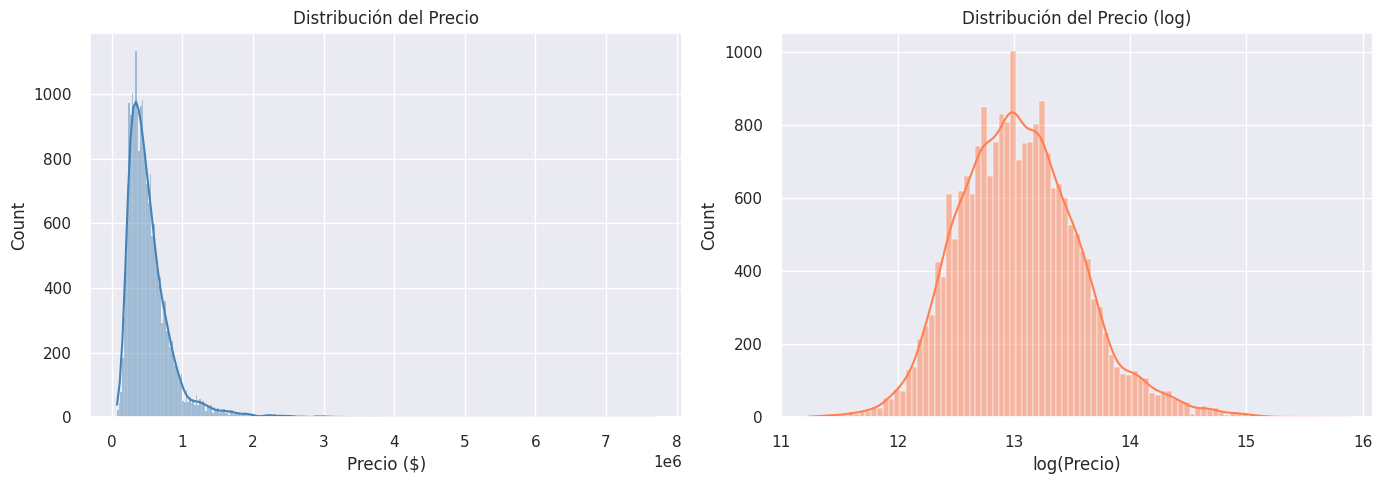

In [44]:
# Distribución de la variable objetivo: precio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_title('Distribución del Precio')
sns.histplot(df['price'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_xlabel('Precio ($)')

axes[1].set_title('Distribución del Precio (log)')
sns.histplot(np.log1p(df['price']), kde=True, ax=axes[1], color='coral')
axes[1].set_xlabel('log(Precio)')

plt.tight_layout()
plt.show()

<Figure size 1400x1000 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Matriz de Correlación')

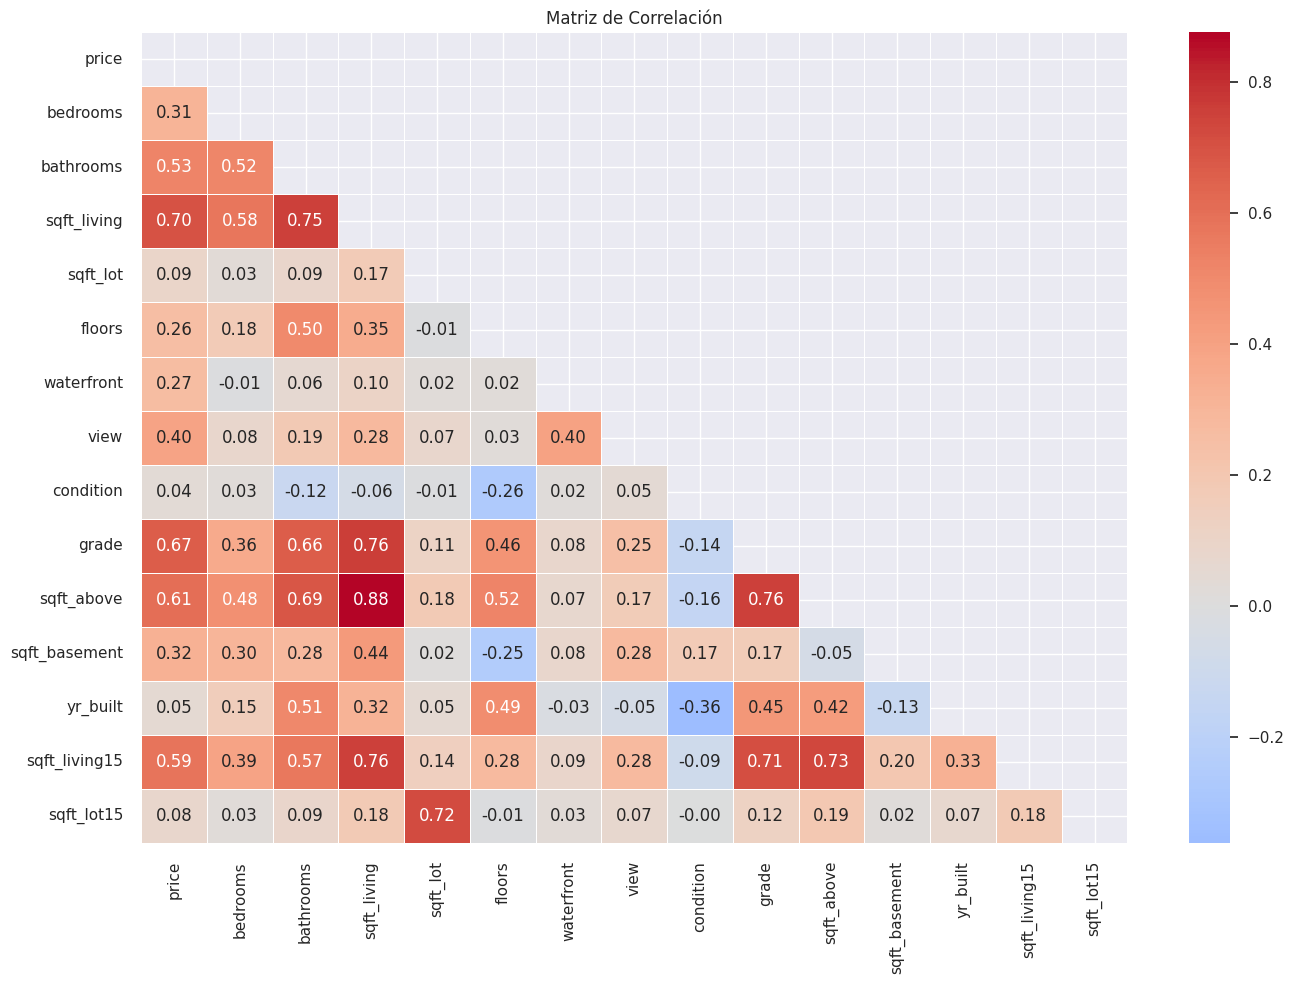

In [45]:
# Matriz de correlación con las variables numéricas principales
numeric_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
                'floors', 'waterfront', 'view', 'condition', 'grade',
                'sqft_above', 'sqft_basement', 'yr_built', 'sqft_living15', 'sqft_lot15']

plt.figure(figsize=(14, 10))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

Text(0.5, 0, 'sqft_living')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'sqft_living vs price')

Text(0.5, 0, 'grade')

Text(0, 0.5, 'price')

...

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'yr_built vs price')

Text(0.5, 0, 'view')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'view vs price')

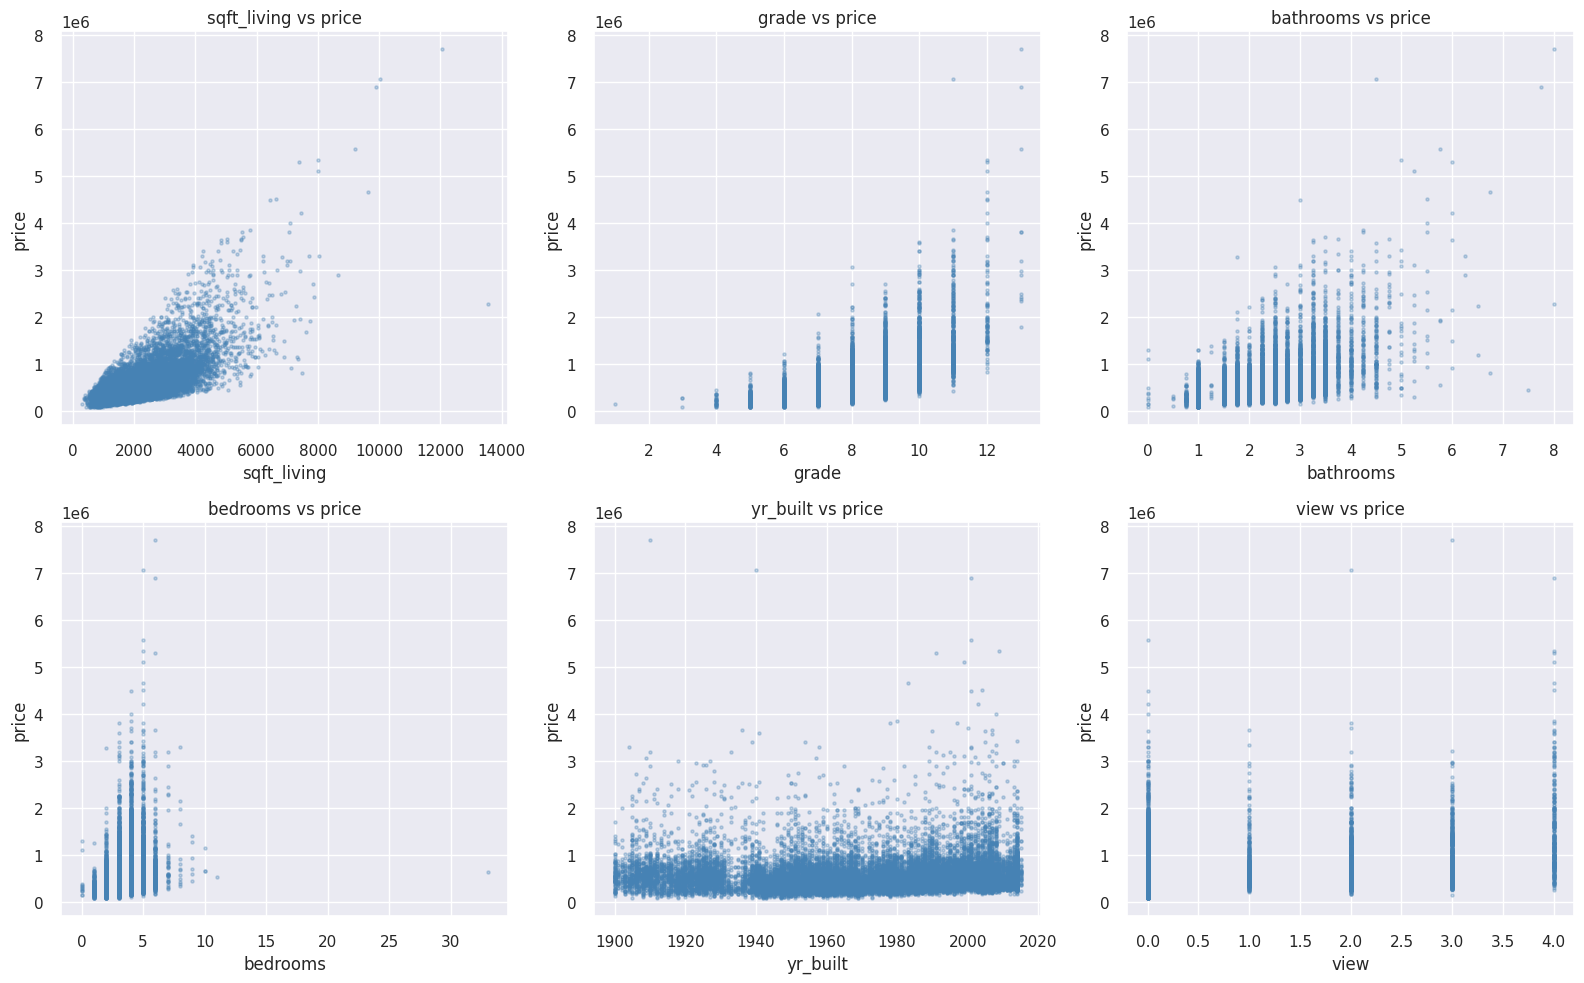

In [46]:
# Relación entre variables clave y precio
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

key_vars = ['sqft_living', 'grade', 'bathrooms', 'bedrooms', 'yr_built', 'view']

for ax, var in zip(axes.flat, key_vars):
    ax.scatter(df[var], df['price'], alpha=0.3, s=5, color='steelblue')
    ax.set_xlabel(var)
    ax.set_ylabel('price')
    ax.set_title(f'{var} vs price')

plt.tight_layout()
plt.show()

<Axes: xlabel='sqft_living', ylabel='Count'>

Text(0.5, 1.0, 'Distribución de sqft_living')

<Axes: xlabel='grade', ylabel='Count'>

Text(0.5, 1.0, 'Distribución de grade')

<Axes: xlabel='bathrooms', ylabel='Count'>

...

Text(0.5, 1.0, 'Distribución de bedrooms')

<Axes: xlabel='yr_built', ylabel='Count'>

Text(0.5, 1.0, 'Distribución de yr_built')

<Axes: xlabel='view', ylabel='Count'>

Text(0.5, 1.0, 'Distribución de view')

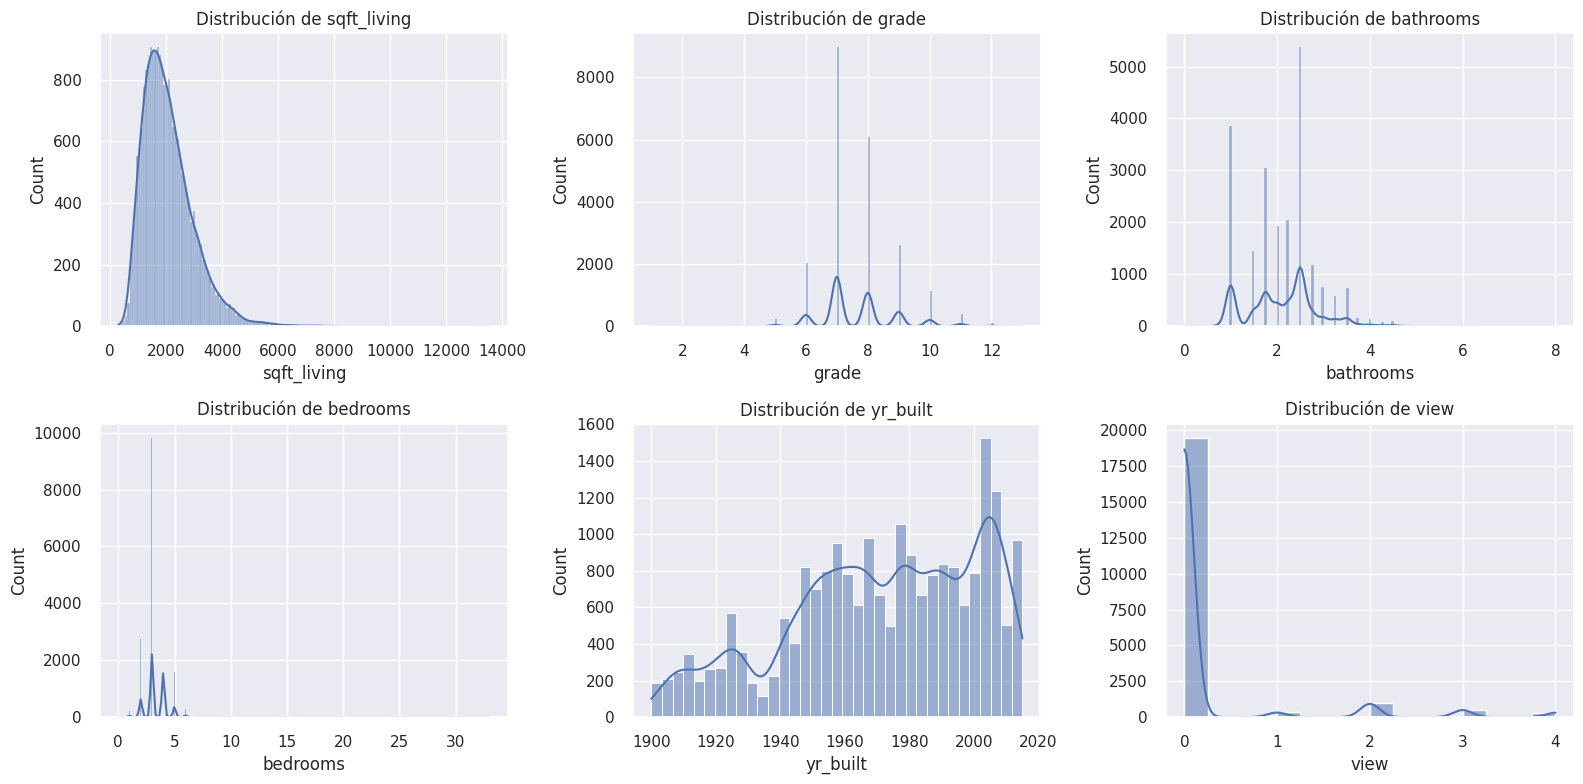

In [47]:
# Distribución de variables numéricas clave
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, var in zip(axes.flat, key_vars):
    sns.histplot(df[var], kde=True, ax=ax)
    ax.set_title(f'Distribución de {var}')

plt.tight_layout()
plt.show()

---
## SECCIÓN 3: Preprocesamiento

In [48]:
# Eliminamos columnas no relevantes para la regresión:
# 'id' es un identificador, 'date' requiere tratamiento temporal que está fuera del alcance
df_model = df.drop(columns=['id', 'date'], errors='ignore')

print(f"Columnas del modelo: {list(df_model.columns)}")
print(f"Shape: {df_model.shape}")

Columnas del modelo: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']
Shape: (21613, 19)


In [49]:
# Eliminamos filas con valores nulos (si los hubiera)
df_model = df_model.dropna()
print(f"Shape tras eliminar nulos: {df_model.shape}")

Shape tras eliminar nulos: (21613, 19)


In [50]:
# Separamos variable objetivo (y) y características (X)
TARGET = 'price'
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Features (18): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']
X shape: (21613, 18)
y shape: (21613,)


---
## SECCIÓN 4: División Train/Test y Estandarización

In [51]:
# División en conjuntos de entrenamiento (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de test: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (17290, 18)
Tamaño del conjunto de test: (4323, 18)


In [52]:
# Estandarización con MinMaxScaler (igual que en el lab de referencia)
# IMPORTANTE: el scaler se ajusta SOLO con datos de entrenamiento
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convertimos a DataFrame para mayor legibilidad
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURES)

X_train_scaled.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0.091,0.219,0.127,1.080e-02,0.0,0.0,0.0,0.75,0.667,0.174,0.000,0.722,0.0,0.207,0.336,0.305,0.405,0.014
1,0.061,0.125,0.060,2.731e-03,0.0,0.0,0.0,0.50,0.417,0.060,0.041,0.252,0.0,0.591,0.635,0.190,0.150,0.005
2,0.091,0.125,0.067,5.983e-03,0.2,0.0,0.0,0.50,0.417,0.082,0.019,0.365,0.0,0.732,0.525,0.153,0.133,0.008
3,0.091,0.281,0.153,5.995e-03,0.0,0.0,0.0,0.75,0.500,0.116,0.168,0.670,0.0,0.152,0.381,0.288,0.241,0.008
4,0.061,0.312,0.123,7.893e-04,0.4,0.0,0.0,0.50,0.583,0.135,0.061,0.930,0.0,0.167,0.881,0.257,0.291,0.011


---
## SECCIÓN 5: Regresión Lineal Simple (OLS)

In [53]:
# Entrenamos el modelo de regresión lineal
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predicciones
y_pred_train = lr.predict(X_train_scaled)
y_pred_test  = lr.predict(X_test_scaled)

# Métricas
print("=== Regresión Lineal (OLS) ===")
print(f"R² Train:  {r2_score(y_train, y_pred_train):.4f}")
print(f"R² Test:   {r2_score(y_test,  y_pred_test):.4f}")
print(f"RMSE Train: {np.sqrt(mean_squared_error(y_train, y_pred_train)):,.2f}")
print(f"RMSE Test:  {np.sqrt(mean_squared_error(y_test,  y_pred_test)):,.2f}")
print(f"MAE Train:  {mean_absolute_error(y_train, y_pred_train):,.2f}")
print(f"MAE Test:   {mean_absolute_error(y_test,  y_pred_test):,.2f}")

LinearRegression()

=== Regresión Lineal (OLS) ===
R² Train:  0.6991
R² Test:   0.7012
RMSE Train: 198,272.24
RMSE Test:  212,539.52
MAE Train:  125,033.16
MAE Test:   127,493.34


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Coefficient', ylabel='Feature'>

Text(0.5, 1.0, 'Coeficientes del Modelo de Regresión Lineal (OLS)')

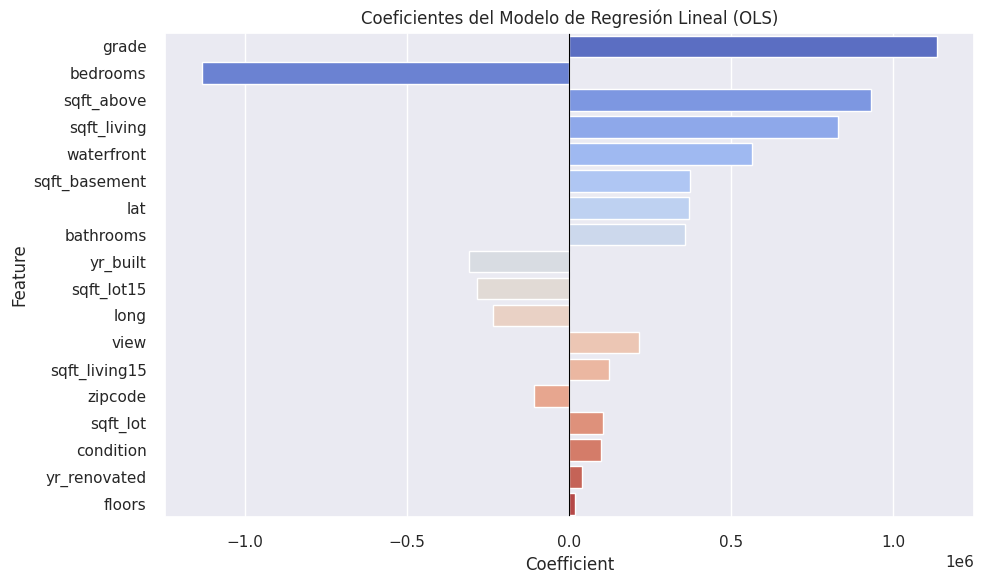

,Feature,Coefficient
8,grade,1.135e+06
0,bedrooms,-1.133e+06
9,sqft_above,9.294e+05
2,sqft_living,8.302e+05
5,waterfront,5.624e+05
10,sqft_basement,3.731e+05
14,lat,3.685e+05
1,bathrooms,3.565e+05
11,yr_built,-3.083e+05
17,sqft_lot15,-2.837e+05


In [54]:
# Coeficientes del modelo OLS
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Coeficientes del Modelo de Regresión Lineal (OLS)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

coef_df

### 5.1 Análisis de Residuos

Text(0.5, 0, 'Valores Predichos')

Text(0, 0.5, 'Residuos')

Text(0.5, 1.0, 'Residuos vs Predichos')

<Axes: xlabel='price', ylabel='Count'>

Text(0.5, 1.0, 'Distribución de Residuos')

Text(0.5, 0, 'Residuos')

((array([-3.59801667, -3.36038867, -3.22930113, ...,  3.22930113,
          3.36038867,  3.59801667]),
  array([-1157598.67070808, -1106950.7234126 ,  -915426.78557679, ...,
          2128086.26744625,  3077289.96667869,  3236267.58706252])),
 (np.float64(185528.33477102657),
  np.float64(3145.2123962870373),
  np.float64(0.8723443510398516)))

Text(0.5, 1.0, 'Q-Q Plot de Residuos')

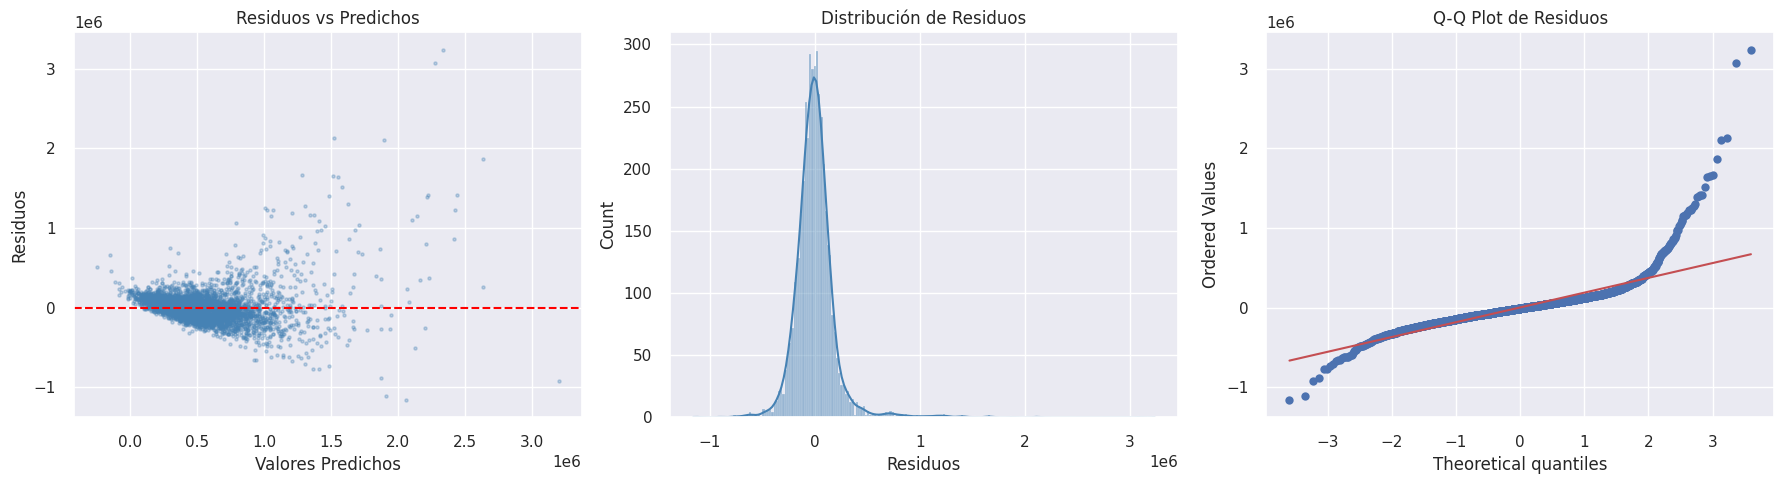

In [55]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuos vs predicciones
axes[0].scatter(y_pred_test, residuals, alpha=0.3, s=5, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores Predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Predichos')

# Distribución de residuos
sns.histplot(residuals, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('Residuos')

# Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot de Residuos')

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Precio Real ($)')

Text(0, 0.5, 'Precio Predicho ($)')

Text(0.5, 1.0, 'Precio Real vs Precio Predicho (OLS)')

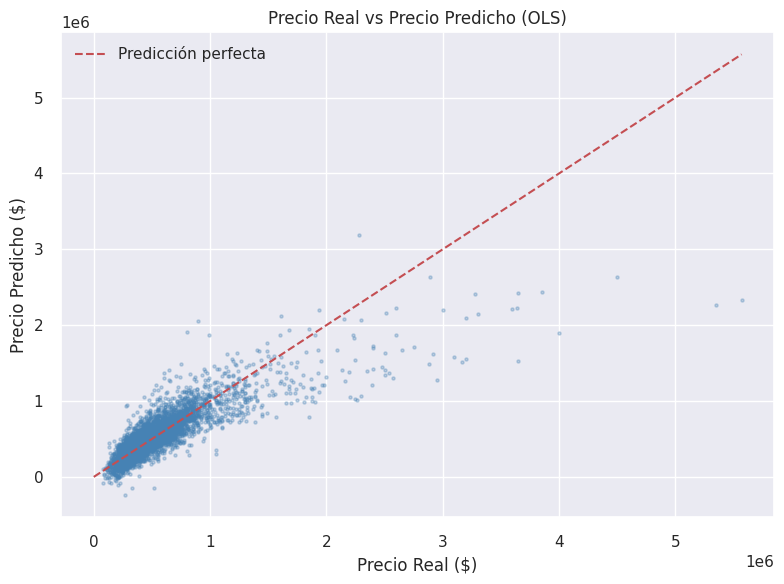

In [56]:
# Valores reales vs predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.3, s=5, color='steelblue')
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Predicción perfecta')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')
plt.title('Precio Real vs Precio Predicho (OLS)')
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Validación Cruzada

In [57]:
# Validación cruzada con K-Fold (k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2_scores = cross_val_score(LinearRegression(), X_train_scaled, y_train,
                               cv=kf, scoring='r2')
cv_rmse_scores = np.sqrt(-cross_val_score(LinearRegression(), X_train_scaled, y_train,
                                          cv=kf, scoring='neg_mean_squared_error'))

print("=== Validación Cruzada (5-Fold) - OLS ===")
print(f"R² CV: {cv_r2_scores.mean():.4f} ± {cv_r2_scores.std():.4f}")
print(f"R² por fold: {cv_r2_scores.round(4)}")
print(f"RMSE CV: {cv_rmse_scores.mean():,.2f} ± {cv_rmse_scores.std():,.2f}")
print(f"RMSE por fold: {cv_rmse_scores.round(2)}")

=== Validación Cruzada (5-Fold) - OLS ===
R² CV: 0.6961 ± 0.0100
R² por fold: [0.7031 0.678  0.7049 0.6928 0.7019]
RMSE CV: 198,791.36 ± 13,312.66
RMSE por fold: [187980.78 197231.51 202241.01 222161.3  184342.19]


### 5.3 Análisis con statsmodels (OLS con p-valores)

In [58]:
# OLS con statsmodels para obtener p-valores y estadísticos
X_train_sm = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train.reset_index(drop=True), X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     2361.
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:21:06   Log-Likelihood:            -2.3543e+05
No. Observations:               17290   AIC:                         4.709e+05
Df Residuals:                   17272   BIC:                         4.710e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -4.387e+05   1.65e+04    -26.622

---
## SECCIÓN 6: Regresión Regularizada — Ridge

In [59]:
# Selección del parámetro alpha mediante RidgeCV con validación cruzada
alphas = np.logspace(-3, 5, 100)

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)

best_alpha_ridge = ridge_cv.alpha_
print(f"Mejor alpha (Ridge): {best_alpha_ridge:.4f}")

RidgeCV(alphas=array([1.00000000e-03, 1.20450354e-03, 1.45082878e-03, 1.74752840e-03,
       2.10490414e-03, 2.53536449e-03, 3.05385551e-03, 3.67837977e-03,
       4.43062146e-03, 5.33669923e-03, 6.42807312e-03, 7.74263683e-03,
       9.32603347e-03, 1.12332403e-02, 1.35304777e-02, 1.62975083e-02,
       1.96304065e-02, 2.36448941e-02, 2.84803587e-02, 3.43046929e-02,
       4.13201240e-02, 4.97702356e-0...
       1.38488637e+03, 1.66810054e+03, 2.00923300e+03, 2.42012826e+03,
       2.91505306e+03, 3.51119173e+03, 4.22924287e+03, 5.09413801e+03,
       6.13590727e+03, 7.39072203e+03, 8.90215085e+03, 1.07226722e+04,
       1.29154967e+04, 1.55567614e+04, 1.87381742e+04, 2.25701972e+04,
       2.71858824e+04, 3.27454916e+04, 3.94420606e+04, 4.75081016e+04,
       5.72236766e+04, 6.89261210e+04, 8.30217568e+04, 1.00000000e+05]),
        cv=5, scoring='r2')

Mejor alpha (Ridge): 0.6734


AlphaSelection(ax=<Axes: >,
               estimator=RidgeCV(alphas=array([1.00000000e-03, 1.20450354e-03, 1.45082878e-03, 1.74752840e-03,
       2.10490414e-03, 2.53536449e-03, 3.05385551e-03, 3.67837977e-03,
       4.43062146e-03, 5.33669923e-03, 6.42807312e-03, 7.74263683e-03,
       9.32603347e-03, 1.12332403e-02, 1.35304777e-02, 1.62975083e-02,
       1.96304065e-02, 2.36448941e-02, 2.84803587e-02, 3.43046...
       1.38488637e+03, 1.66810054e+03, 2.00923300e+03, 2.42012826e+03,
       2.91505306e+03, 3.51119173e+03, 4.22924287e+03, 5.09413801e+03,
       6.13590727e+03, 7.39072203e+03, 8.90215085e+03, 1.07226722e+04,
       1.29154967e+04, 1.55567614e+04, 1.87381742e+04, 2.25701972e+04,
       2.71858824e+04, 3.27454916e+04, 3.94420606e+04, 4.75081016e+04,
       5.72236766e+04, 6.89261210e+04, 8.30217568e+04, 1.00000000e+05]),
                                 store_cv_values=True))

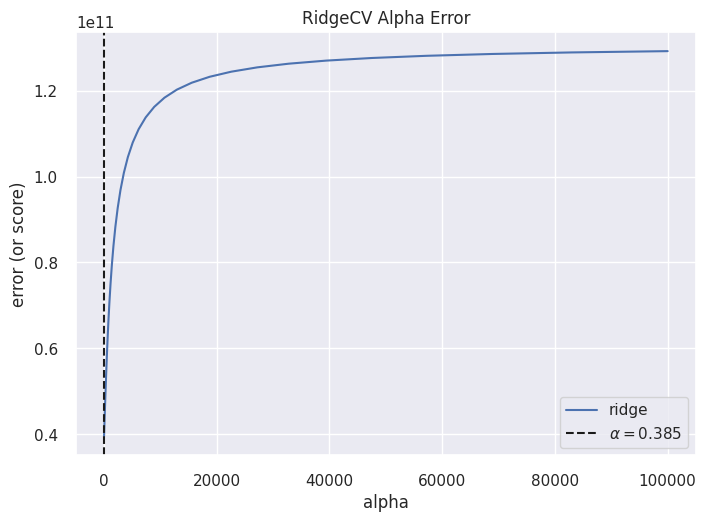

<Axes: title={'center': 'RidgeCV Alpha Error'}, xlabel='alpha', ylabel='error (or score)'>

In [60]:
from yellowbrick.regressor import AlphaSelection
from sklearn.linear_model import RidgeCV
import matplotlib.pyplot as plt

ridge_cv = RidgeCV(alphas=alphas)

viz = AlphaSelection(ridge_cv)
viz.fit(X_train_scaled, y_train)
viz.show()



In [61]:
# Entrenamos Ridge con el mejor alpha
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge_train = ridge.predict(X_train_scaled)
y_pred_ridge_test  = ridge.predict(X_test_scaled)

print("=== Ridge Regression ===")
print(f"Alpha: {best_alpha_ridge:.4f}")
print(f"R² Train:  {r2_score(y_train, y_pred_ridge_train):.4f}")
print(f"R² Test:   {r2_score(y_test,  y_pred_ridge_test):.4f}")
print(f"RMSE Train: {np.sqrt(mean_squared_error(y_train, y_pred_ridge_train)):,.2f}")
print(f"RMSE Test:  {np.sqrt(mean_squared_error(y_test,  y_pred_ridge_test)):,.2f}")
print(f"MAE Train:  {mean_absolute_error(y_train, y_pred_ridge_train):,.2f}")
print(f"MAE Test:   {mean_absolute_error(y_test,  y_pred_ridge_test):,.2f}")

Ridge(alpha=np.float64(0.6734150657750828))

=== Ridge Regression ===
Alpha: 0.6734
R² Train:  0.6991
R² Test:   0.7009
RMSE Train: 198,286.04
RMSE Test:  212,656.74
MAE Train:  124,879.28
MAE Test:   127,403.99


<Axes: xlabel='Coef_OLS', ylabel='Feature'>

Text(0.5, 1.0, 'Coeficientes OLS')

<Axes: xlabel='Coef_Ridge', ylabel='Feature'>

Text(0.5, 1.0, 'Coeficientes Ridge (α=0.67)')

Text(0.5, 0.98, 'Comparación de Coeficientes: OLS vs Ridge')

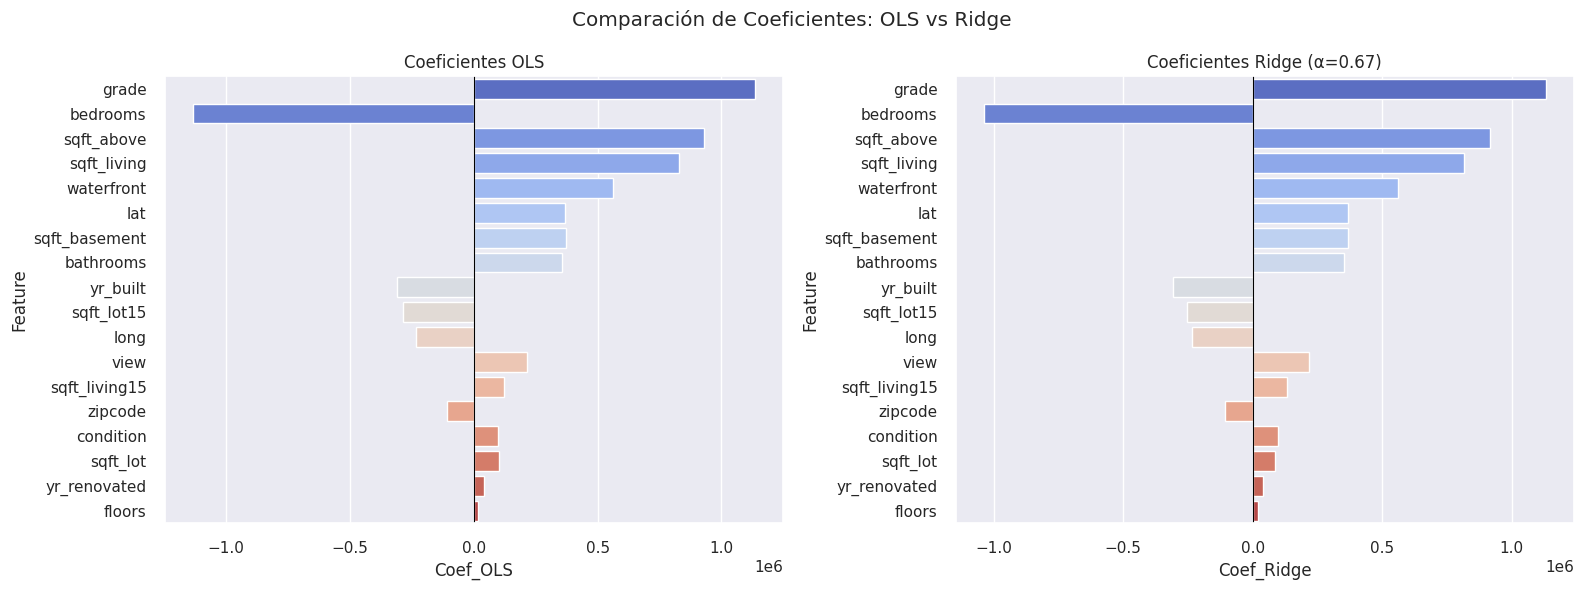

In [62]:
# Coeficientes Ridge
ridge_coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coef_OLS': lr.coef_,
    'Coef_Ridge': ridge.coef_
}).sort_values('Coef_Ridge', key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=ridge_coef_df, x='Coef_OLS', y='Feature', ax=axes[0], palette='coolwarm')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Coeficientes OLS')

sns.barplot(data=ridge_coef_df, x='Coef_Ridge', y='Feature', ax=axes[1], palette='coolwarm')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title(f'Coeficientes Ridge (α={best_alpha_ridge:.2f})')

plt.suptitle('Comparación de Coeficientes: OLS vs Ridge')
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Valores Predichos')

Text(0, 0.5, 'Residuos')

Text(0.5, 1.0, 'Residuos vs Predichos (Ridge)')

<Axes: xlabel='price', ylabel='Count'>

Text(0.5, 1.0, 'Distribución de Residuos (Ridge)')

((array([-3.59801667, -3.36038867, -3.22930113, ...,  3.22930113,
          3.36038867,  3.59801667]),
  array([-1150165.98582937, -1102191.7359689 ,  -900895.66764915, ...,
          2129560.51143266,  3085582.737255  ,  3251333.80604146])),
 (np.float64(185415.3952300001),
  np.float64(3204.2328919748384),
  np.float64(0.8713362453725556)))

Text(0.5, 1.0, 'Q-Q Plot de Residuos (Ridge)')

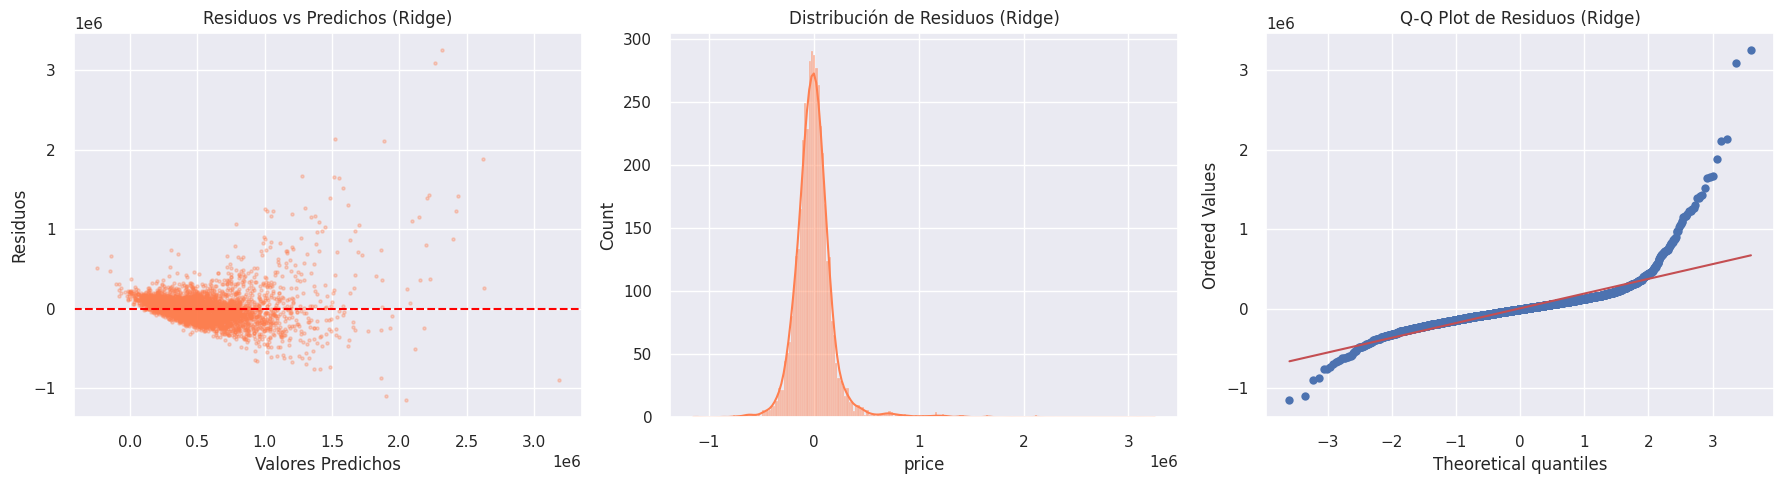

In [63]:
# Análisis de residuos Ridge
residuals_ridge = y_test - y_pred_ridge_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_ridge_test, residuals_ridge, alpha=0.3, s=5, color='coral')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores Predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Predichos (Ridge)')

sns.histplot(residuals_ridge, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribución de Residuos (Ridge)')

stats.probplot(residuals_ridge, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot de Residuos (Ridge)')

plt.tight_layout()
plt.show()

---
## SECCIÓN 7: Regresión Regularizada — LASSO

In [64]:
# Selección del parámetro alpha mediante LassoCV con validación cruzada
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

best_alpha_lasso = lasso_cv.alpha_
print(f"Mejor alpha (Lasso): {best_alpha_lasso:.4f}")

LassoCV(alphas=array([1.00000000e-03, 1.20450354e-03, 1.45082878e-03, 1.74752840e-03,
       2.10490414e-03, 2.53536449e-03, 3.05385551e-03, 3.67837977e-03,
       4.43062146e-03, 5.33669923e-03, 6.42807312e-03, 7.74263683e-03,
       9.32603347e-03, 1.12332403e-02, 1.35304777e-02, 1.62975083e-02,
       1.96304065e-02, 2.36448941e-02, 2.84803587e-02, 3.43046929e-02,
       4.13201240e-02, 4.97702356e-0...
       1.38488637e+03, 1.66810054e+03, 2.00923300e+03, 2.42012826e+03,
       2.91505306e+03, 3.51119173e+03, 4.22924287e+03, 5.09413801e+03,
       6.13590727e+03, 7.39072203e+03, 8.90215085e+03, 1.07226722e+04,
       1.29154967e+04, 1.55567614e+04, 1.87381742e+04, 2.25701972e+04,
       2.71858824e+04, 3.27454916e+04, 3.94420606e+04, 4.75081016e+04,
       5.72236766e+04, 6.89261210e+04, 8.30217568e+04, 1.00000000e+05]),
        cv=5, max_iter=10000, random_state=42)

Mejor alpha (Lasso): 13.2194


In [65]:
# Entrenamos Lasso con el mejor alpha
lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso_train = lasso.predict(X_train_scaled)
y_pred_lasso_test  = lasso.predict(X_test_scaled)

print("=== Lasso Regression ===")
print(f"Alpha: {best_alpha_lasso:.4f}")
print(f"R² Train:  {r2_score(y_train, y_pred_lasso_train):.4f}")
print(f"R² Test:   {r2_score(y_test,  y_pred_lasso_test):.4f}")
print(f"RMSE Train: {np.sqrt(mean_squared_error(y_train, y_pred_lasso_train)):,.2f}")
print(f"RMSE Test:  {np.sqrt(mean_squared_error(y_test,  y_pred_lasso_test)):,.2f}")
print(f"MAE Train:  {mean_absolute_error(y_train, y_pred_lasso_train):,.2f}")
print(f"MAE Test:   {mean_absolute_error(y_test,  y_pred_lasso_test):,.2f}")

# Coeficientes puestos a cero por Lasso (selección de características)
n_zero = np.sum(lasso.coef_ == 0)
print(f"\nCoeficientes puestos a 0 por Lasso: {n_zero} / {len(FEATURES)}")

Lasso(alpha=np.float64(13.219411484660315), max_iter=10000)

=== Lasso Regression ===
Alpha: 13.2194
R² Train:  0.6991
R² Test:   0.7010
RMSE Train: 198,277.08
RMSE Test:  212,614.51
MAE Train:  124,962.52
MAE Test:   127,475.68

Coeficientes puestos a 0 por Lasso: 1 / 18


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Coef_Lasso', ylabel='Feature'>

Text(0.5, 1.0, 'Coeficientes LASSO (α=13.22) — Gris = eliminado')

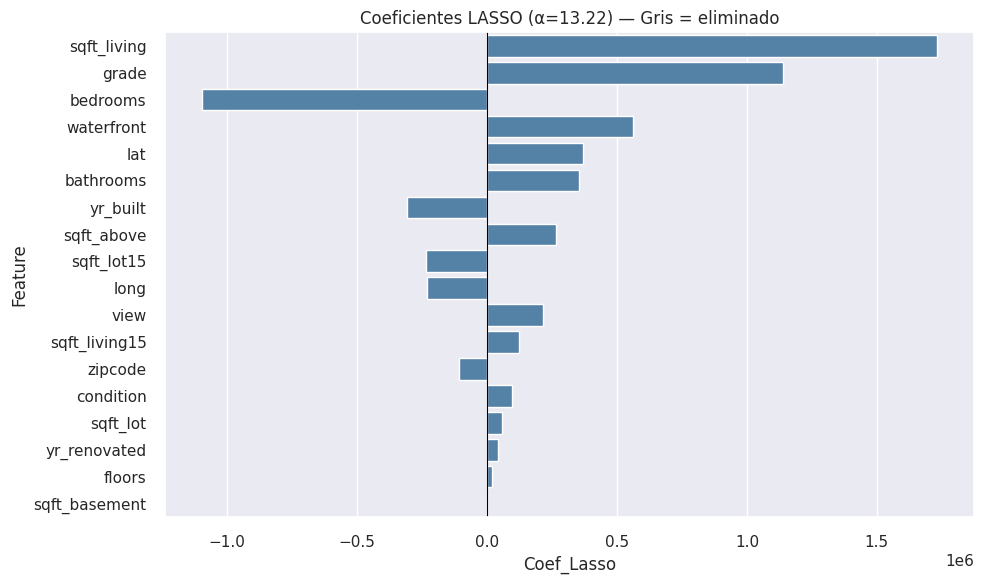

,Feature,Coef_Lasso
2,sqft_living,1.732e+06
8,grade,1.137e+06
0,bedrooms,-1.099e+06
5,waterfront,5.610e+05
14,lat,3.684e+05
1,bathrooms,3.532e+05
11,yr_built,-3.078e+05
9,sqft_above,2.656e+05
17,sqft_lot15,-2.333e+05
15,long,-2.322e+05


In [66]:
# Coeficientes Lasso — selección de características
lasso_coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coef_Lasso': lasso.coef_
}).sort_values('Coef_Lasso', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if c != 0 else 'lightgray' for c in lasso_coef_df['Coef_Lasso']]
sns.barplot(data=lasso_coef_df, x='Coef_Lasso', y='Feature', palette=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Coeficientes LASSO (α={best_alpha_lasso:.2f}) — Gris = eliminado')
plt.tight_layout()
plt.show()

lasso_coef_df

Text(0.5, 0, 'Valores Predichos')

Text(0, 0.5, 'Residuos')

Text(0.5, 1.0, 'Residuos vs Predichos (Lasso)')

<Axes: xlabel='price', ylabel='Count'>

Text(0.5, 1.0, 'Distribución de Residuos (Lasso)')

((array([-3.59801667, -3.36038867, -3.22930113, ...,  3.22930113,
          3.36038867,  3.59801667]),
  array([-1155708.0696074 , -1105884.72458855,  -910398.11712858, ...,
          2128568.74834559,  3080020.59297989,  3240713.09768454])),
 (np.float64(185520.42475178555),
  np.float64(3206.2268461108306),
  np.float64(0.8720031512599868)))

Text(0.5, 1.0, 'Q-Q Plot de Residuos (Lasso)')

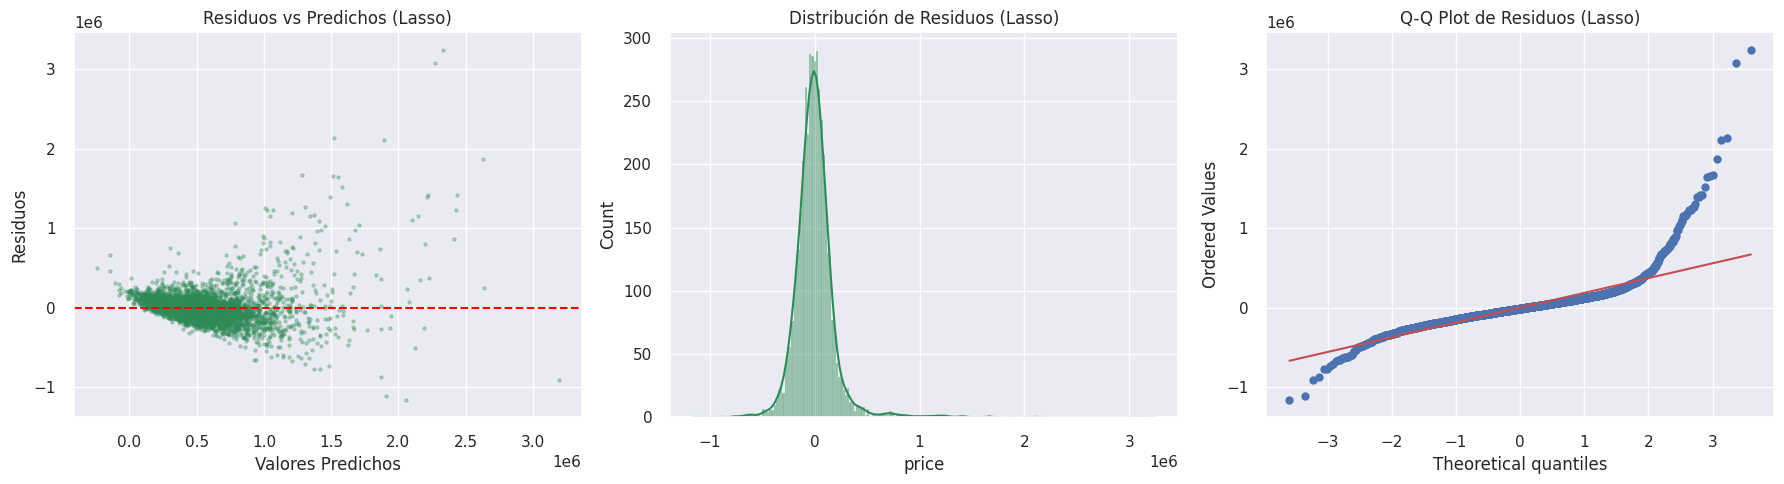

In [67]:
# Análisis de residuos Lasso
residuals_lasso = y_test - y_pred_lasso_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_lasso_test, residuals_lasso, alpha=0.3, s=5, color='seagreen')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores Predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Predichos (Lasso)')

sns.histplot(residuals_lasso, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribución de Residuos (Lasso)')

stats.probplot(residuals_lasso, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot de Residuos (Lasso)')

plt.tight_layout()
plt.show()

---
## SECCIÓN 8: Comparación Final de Modelos

In [68]:
# Tabla comparativa
results = pd.DataFrame({
    'Modelo': ['OLS', 'Ridge', 'Lasso'],
    'R² Train': [
        r2_score(y_train, y_pred_train),
        r2_score(y_train, y_pred_ridge_train),
        r2_score(y_train, y_pred_lasso_train)
    ],
    'R² Test': [
        r2_score(y_test, y_pred_test),
        r2_score(y_test, y_pred_ridge_test),
        r2_score(y_test, y_pred_lasso_test)
    ],
    'RMSE Test': [
        np.sqrt(mean_squared_error(y_test, y_pred_test)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge_test)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
    ],
    'MAE Test': [
        mean_absolute_error(y_test, y_pred_test),
        mean_absolute_error(y_test, y_pred_ridge_test),
        mean_absolute_error(y_test, y_pred_lasso_test)
    ]
})

results = results.set_index('Modelo')
print("=== Comparación Final de Modelos ===")
results

=== Comparación Final de Modelos ===


,R² Train,R² Test,RMSE Test,MAE Test
Modelo,,,,
OLS,0.699,0.701,212539.517,127493.342
Ridge,0.699,0.701,212656.741,127403.989
Lasso,0.699,0.701,212614.510,127475.675


<Axes: xlabel='Modelo'>

Text(0.5, 1.0, 'Comparación R²')

(0.0, 1.0)

[Text(0, 0, 'OLS'), Text(1, 0, 'Ridge'), Text(2, 0, 'Lasso')]

<Axes: xlabel='Modelo'>

Text(0.5, 1.0, 'RMSE en Test')

[Text(0, 0, 'OLS'), Text(1, 0, 'Ridge'), Text(2, 0, 'Lasso')]

Text(0.5, 0.98, 'Comparación de Modelos: OLS vs Ridge vs Lasso')

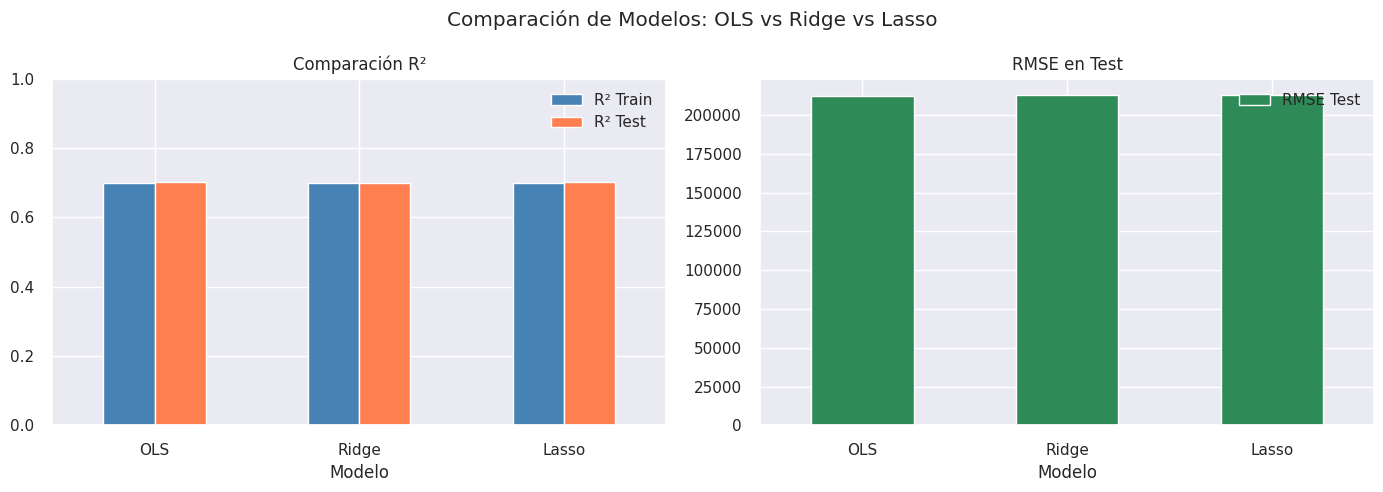

In [69]:
# Visualización comparativa de R² y RMSE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results[['R² Train', 'R² Test']].plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Comparación R²')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(results.index, rotation=0)
axes[0].legend()

results[['RMSE Test']].plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('RMSE en Test')
axes[1].set_xticklabels(results.index, rotation=0)

plt.suptitle('Comparación de Modelos: OLS vs Ridge vs Lasso')
plt.tight_layout()
plt.show()

<Axes: xlabel='Feature'>

Text(0.5, 1.0, 'Comparación de Coeficientes: OLS vs Ridge vs Lasso')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17]),
 [Text(0, 0, 'grade'),
  Text(1, 0, 'bedrooms'),
  Text(2, 0, 'sqft_above'),
  Text(3, 0, 'sqft_living'),
  Text(4, 0, 'waterfront'),
  Text(5, 0, 'sqft_basement'),
  Text(6, 0, 'lat'),
  Text(7, 0, 'bathrooms'),
  Text(8, 0, 'yr_built'),
  Text(9, 0, 'sqft_lot15'),
  Text(10, 0, 'long'),
  Text(11, 0, 'view'),
  Text(12, 0, 'sqft_living15'),
  Text(13, 0, 'zipcode'),
  Text(14, 0, 'sqft_lot'),
  Text(15, 0, 'condition'),
  Text(16, 0, 'yr_renovated'),
  Text(17, 0, 'floors')])

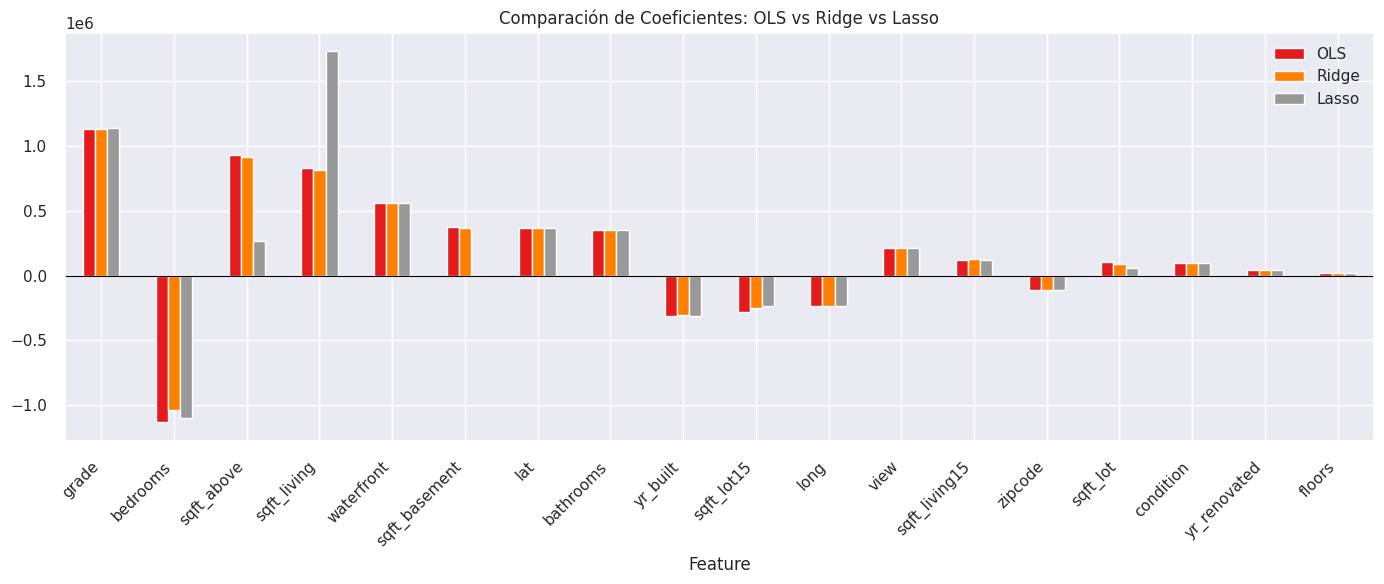

In [70]:
# Comparación de coeficientes entre los tres modelos
compare_coef = pd.DataFrame({
    'Feature': FEATURES,
    'OLS':   lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
}).set_index('Feature').sort_values('OLS', key=abs, ascending=False)

compare_coef.plot(kind='bar', figsize=(14, 6), colormap='Set1')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Comparación de Coeficientes: OLS vs Ridge vs Lasso')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Conclusiones

### Resultados obtenidos:

- **OLS (Regresión Lineal Clásica)**: El modelo base explica aproximadamente el **~70% de la varianza** del precio. Los residuos presentan cierta heterocedasticidad (varianza no constante), especialmente para casas de precio muy alto, lo que es habitual en datos de precios inmobiliarios.

- **Ridge Regression**: Introduce regularización L2 que penaliza coeficientes grandes pero **no los elimina**. Los resultados son muy similares a OLS en este dataset, lo que sugiere que no hay mucho overfitting en el modelo base.

- **Lasso Regression**: Introduce regularización L1 que puede **llevar coeficientes exactamente a 0**, haciendo una selección automática de características. Es útil para identificar cuáles son las variables más relevantes.

### Variables más relevantes:
- `sqft_living`: Superficie habitable → mayor impacto positivo en el precio
- `grade`: Calidad de construcción → muy relevante
- `lat`: Latitud → componente geográfica importante (barrios de Seattle)
- `waterfront`: Vistas al agua → incrementa considerablemente el precio
- `view`: Calidad de vistas → impacto positivo

### Limitaciones:
- No se ha transformado la variable `price` (que tiene distribución sesgada hacia la derecha). Una transformación logarítmica podría mejorar los modelos.
- No se han creado features derivadas (p.ej. edad de la casa = año actual - yr_built).
- La componente geográfica (lat, long) podría modelarse de forma más sofisticada.